# 03 — E-Perf-6: per-node RSS scaling

RFC-008 §E-Perf-6. Renders per-depth steady-state RSS from the
`eval/scripts/run-e-perf-6-8-shakedown.sh` memory sampler (1 Hz `ps`).

**Inputs**: `eval/results/e-perf-6/<host-tag>-<ts>/depth-{1,3,5,10}/run-NN/memory.csv`

**Configure** with `SHAKEDOWN_DIR` env var; otherwise newest shakedown is used.

In [1]:
import json, os, glob, csv, statistics
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

REPO = Path.cwd()
while REPO != REPO.parent and not (REPO / 'eval').is_dir():
    REPO = REPO.parent

shakedown_dir = os.environ.get('SHAKEDOWN_DIR')
if not shakedown_dir:
    candidates = sorted(glob.glob(str(REPO / 'eval/results/e-perf-6/shakedown-macos-*')))
    if not candidates:
        raise RuntimeError('no shakedown directory under eval/results/e-perf-6/')
    shakedown_dir = candidates[-1]
shakedown_dir = Path(shakedown_dir)
print(f'shakedown: {shakedown_dir.relative_to(REPO)}')

shakedown: eval/results/e-perf-6/shakedown-macos-2026-07-22T17-49-56Z


In [2]:
DEPTHS = [1, 3, 5, 10]

# Extract steady-state RSS per run (last 3 samples = post-startup)
rows = []
for depth in DEPTHS:
    depth_dir = shakedown_dir / f'depth-{depth}'
    for run_dir in sorted(depth_dir.glob('run-*')):
        mem_csv = run_dir / 'memory.csv'
        if not mem_csv.exists():
            continue
        with open(mem_csv) as f:
            reader = csv.DictReader(f)
            samples = [int(row['rss_kb']) for row in reader]
        if len(samples) < 2:
            continue
        # Steady-state: last N-1 samples (skip startup spike)
        steady = samples[1:]
        rows.append({
            'depth': depth,
            'run': run_dir.name,
            'rss_kb_median': statistics.median(steady),
            'rss_kb_max': max(steady),
            'n_samples': len(samples),
        })

df = pd.DataFrame(rows)
summary = df.groupby('depth').agg(
    median_rss_kb=('rss_kb_median', 'median'),
    mean_rss_kb=('rss_kb_median', 'mean'),
    stdev_rss_kb=('rss_kb_median', 'std'),
    n=('rss_kb_median', 'count'),
).reset_index()
summary['rss_mb'] = summary['median_rss_kb'] / 1024
print(summary.to_string(index=False))

 depth  median_rss_kb  mean_rss_kb  stdev_rss_kb  n    rss_mb
     1        35464.0 35547.466667    535.349820 30 34.632812
     3        39936.0 39977.333333    792.945679 30 39.000000
     5        41804.0 41968.266667    677.258517 30 40.824219
    10        46152.0 46299.733333    678.164609 30 45.070312


In [3]:
# Linear fit: RSS = intercept + slope * depth
from numpy.polynomial import polynomial as P

x = summary['depth'].values.astype(float)
y = summary['median_rss_kb'].values.astype(float)

coeffs = np.polyfit(x, y, 1)  # [slope, intercept]
slope, intercept = coeffs
y_pred = np.polyval(coeffs, x)
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r_sq = 1 - ss_res / ss_tot

print(f'RSS slope: {slope:.0f} KB/hop ({slope/1024:.2f} MB/hop)')
print(f'Intercept: {intercept:.0f} KB ({intercept/1024:.1f} MB)')
print(f'R²: {r_sq:.4f}')

RSS slope: 1114 KB/hop (1.09 MB/hop)
Intercept: 35545 KB (34.7 MB)
R²: 0.9442


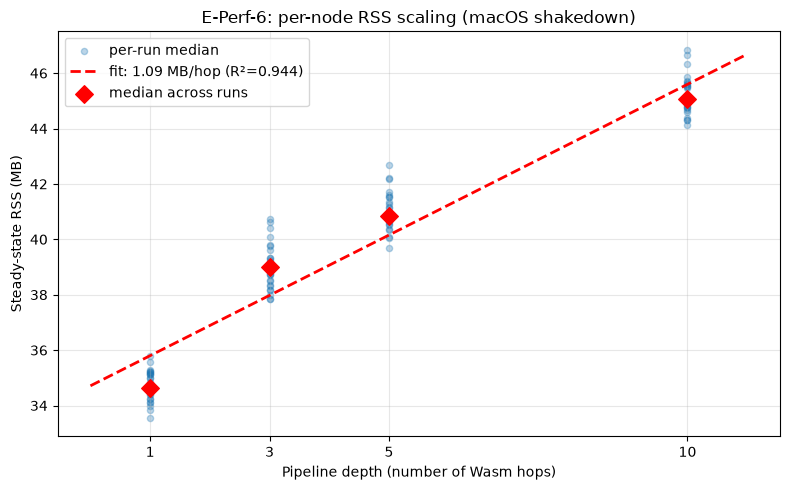

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

# Scatter: per-run medians
ax.scatter(df['depth'], df['rss_kb_median'] / 1024, alpha=0.3, s=20, label='per-run median')

# Line: linear fit
x_fit = np.linspace(0, 11, 50)
y_fit = (slope * x_fit + intercept) / 1024
ax.plot(x_fit, y_fit, 'r--', linewidth=2,
        label=f'fit: {slope/1024:.2f} MB/hop (R²={r_sq:.3f})')

# Median markers
ax.scatter(summary['depth'], summary['rss_mb'], color='red', s=80, zorder=5,
           marker='D', label='median across runs')

ax.set_xlabel('Pipeline depth (number of Wasm hops)')
ax.set_ylabel('Steady-state RSS (MB)')
ax.set_title('E-Perf-6: per-node RSS scaling (macOS shakedown)')
ax.legend()
ax.set_xticks(DEPTHS)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Interpretation

The slope represents the per-Wasm-node RSS cost: each additional pass-through
transform adds ~1 MB of steady-state RSS. The intercept (~35 MB) is the
fixed runtime overhead (wasmtime engine, tokio runtime, channels, bench
source/sink).

**macOS caveat**: `ps` RSS on macOS includes shared libraries and
memory-mapped regions that would be shared across processes on Linux.
Pi canonical numbers will use `/proc/<pid>/smaps_rollup` for accurate
RSS (Rss - Shared_Clean - Shared_Dirty = private RSS).